In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

random_state = 333

In this excercise we are presenting SHAP analysis for `RandomForestClassifier`. We use file `adult-income-dataset.csv`, so now lets load up data and clean them by dropning null values.

In [117]:
adult_income_df = pd.read_csv('./../datasets/adult-income-dataset.csv')
adult_income_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [118]:
adult_income_df = adult_income_df.replace("?", np.nan)

before_dropna = adult_income_df.shape
adult = adult_income_df.dropna().copy()
after_dropna = adult.shape

print(f"Before dropping nan values: {before_dropna}")
print(f"After dropping nan values: {after_dropna}")

Before dropping nan values: (48842, 15)
After dropping nan values: (45222, 15)


Now we divide data into input features and target (income) column.

In [119]:
adult['income'].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

As we see target is binary: `$<=50K = 0$` and `$>50K = 1$`.

In [120]:
adult["income"] = adult["income"].map({"<=50K": 0, ">50K": 1})

Becouse dataset contains many categorical columns, we need to check it.

In [121]:
categorical_cols = X.select_dtypes(include="str").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

Categorical columns: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [122]:
adult[categorical_cols].head()

,workclass,marital-status,occupation,relationship,race,gender,native-country
0,Private,Never-married,Machine-op-inspct,Own-child,Black,Male,United-States
1,Private,Married-civ-spouse,Farming-fishing,Husband,White,Male,United-States
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,White,Male,United-States
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,United-States
5,Private,Never-married,Other-service,Not-in-family,White,Male,United-States


In [123]:
adult[['education', 'educational-num']].head()

,education,educational-num
0,11th,7
1,HS-grad,9
2,Assoc-acdm,12
3,Some-college,10
5,10th,6


This one ordinal category is also written in number (we suppose), so lets drop it.

In [124]:
adult.drop(columns=["education"], inplace=True)
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='str')

Lets check one more propably big column `native-country`

In [125]:
adult['native-country'].unique()

<StringArray>
[             'United-States',                       'Peru',
                  'Guatemala',                     'Mexico',
         'Dominican-Republic',                    'Ireland',
                    'Germany',                'Philippines',
                   'Thailand',                      'Haiti',
                'El-Salvador',                'Puerto-Rico',
                    'Vietnam',                      'South',
                   'Columbia',                      'Japan',
                      'India',                   'Cambodia',
                     'Poland',                       'Laos',
                    'England',                       'Cuba',
                     'Taiwan',                      'Italy',
                     'Canada',                   'Portugal',
                      'China',                  'Nicaragua',
                   'Honduras',                       'Iran',
                   'Scotland',                    'Jamaica',
          

It's seems to much for nice simple decision tree, so I with the power of AI (like solution when maybe there is 200 unique values), we divide them into groups by region.

In [126]:
def map_country_to_region(country):
    europe = {
        "England", "Germany", "Greece", "Italy", "Poland", "Portugal",
        "France", "Ireland", "Scotland", "Hungary", "Yugoslavia",
        "Holand-Netherlands"
    }
    
    asia = {
        "India", "Japan", "China", "Iran", "Philippines", "Vietnam",
        "Cambodia", "Thailand", "Laos", "Taiwan", "Hong", "South"
    }
    
    latin_america = {
        "Mexico", "Puerto-Rico", "Honduras", "Jamaica", "Cuba",
        "Dominican-Republic", "El-Salvador", "Guatemala", "Haiti",
        "Nicaragua", "Peru", "Ecuador", "Trinadad&Tobago", "Columbia"
    }
    
    if country == "United-States":
        return "United-States"
    elif country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in latin_america:
        return "Latin-America"
    else:
        return "Other"

In [127]:
adult["native-country"] = adult["native-country"].apply(map_country_to_region)
adult.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [128]:
adult['native-country'].unique()

<StringArray>
['United-States', 'Latin-America', 'Europe', 'Asia', 'Other']
Length: 5, dtype: str

Everything else seems okey to use one hot encoding.

In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (36177, 13), (36177,)
Test set: (9045, 13), (9045,)


In [131]:
X = adult.drop(columns=["income"])
y = adult["income"]

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

X_train_encoded_df.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,race_Black,race_Other,race_White,gender_Female,gender_Male,native-country_Asia,native-country_Europe,native-country_Latin-America,native-country_Other,native-country_United-States
19133,54.0,32778.0,9.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4784,74.0,148867.0,10.0,6418.0,0.0,24.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
47510,29.0,176037.0,11.0,14344.0,0.0,40.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3097,36.0,126675.0,13.0,0.0,0.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1936,41.0,194537.0,13.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [132]:
print(feature_names)

['age' 'fnlwgt' 'educational-num' 'capital-gain' 'capital-loss'
 'hours-per-week' 'workclass_Federal-gov' 'workclass_Local-gov'
 'workclass_Private' 'workclass_Self-emp-inc' 'workclass_Self-emp-not-inc'
 'workclass_State-gov' 'workclass_Without-pay' 'marital-status_Divorced'
 'marital-status_Married-AF-spouse' 'marital-status_Married-civ-spouse'
 'marital-status_Married-spouse-absent' 'marital-status_Never-married'
 'marital-status_Separated' 'marital-status_Widowed'
 'occupation_Adm-clerical' 'occupation_Armed-Forces'
 'occupation_Craft-repair' 'occupation_Exec-managerial'
 'occupation_Farming-fishing' 'occupation_Handlers-cleaners'
 'occupation_Machine-op-inspct' 'occupation_Other-service'
 'occupation_Priv-house-serv' 'occupation_Prof-specialty'
 'occupation_Protective-serv' 'occupation_Sales' 'occupation_Tech-support'
 'occupation_Transport-moving' 'relationship_Husband'
 'relationship_Not-in-family' 'relationship_Other-relative'
 'relationship_Own-child' 'relationship_Unmarried' '

Then we train Random Forest classifier. We also check simple metrics, just to verify that model works correctly.

In [139]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": random_state,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    scores = cross_val_score(
        model,
        X_train_encoded_df,
        y_train,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-06 19:05:01,753] A new study created in memory with name: no-name-4ae9e306-3996-4562-85f3-52e9e8346fd7
[I 2026-03-06 19:05:03,292] Trial 0 finished with value: 0.8951746600017927 and parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8951746600017927.
[I 2026-03-06 19:05:07,806] Trial 1 finished with value: 0.9102282314377076 and parameters: {'n_estimators': 600, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 1 with value: 0.9102282314377076.
[I 2026-03-06 19:05:10,050] Trial 2 finished with value: 0.9001963283473383 and parameters: {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9102282314377076.
[I 2026-03-06 19:05:12,296] Trial 3 finished with value: 0.9040294859437247 and parameters: {'n_estimators': 600, 'max_depth': 6, 'min_s

Best score: 0.9131254128497012
Best params: {'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}


In [140]:
rf_model = RandomForestClassifier(
    **study.best_params,
    random_state=random_state,
    n_jobs=-1
)

rf_model.fit(X_train_encoded_df, y_train)

y_pred = rf_model.predict(X_test_encoded_df)
y_proba = rf_model.predict_proba(X_test_encoded_df)[:, 1]

And display the results

In [141]:
print(f"accuracy {accuracy_score(y_test, y_pred):.4f}")

accuracy 0.8568


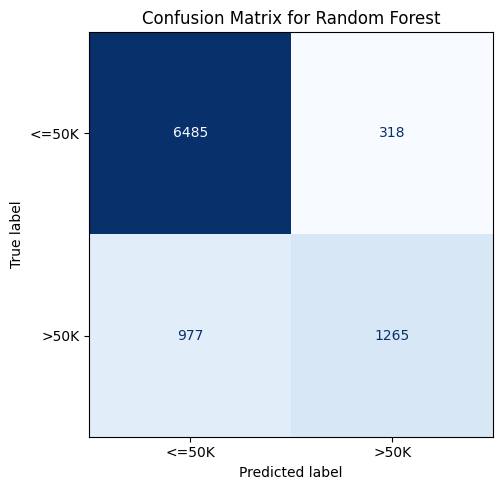

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix for our model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Now we calculate SHAP values for all test samples. For binary classification SHAP can return values for both classes, so we keep explanation for positive class `$>50K$`.

In [145]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_encoded_df)

if len(shap_values.values.shape) == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print("SHAP values shape for class >50K:", shap_values_pos.values.shape)

SHAP values shape for class >50K: (9045, 52)


lets visualize

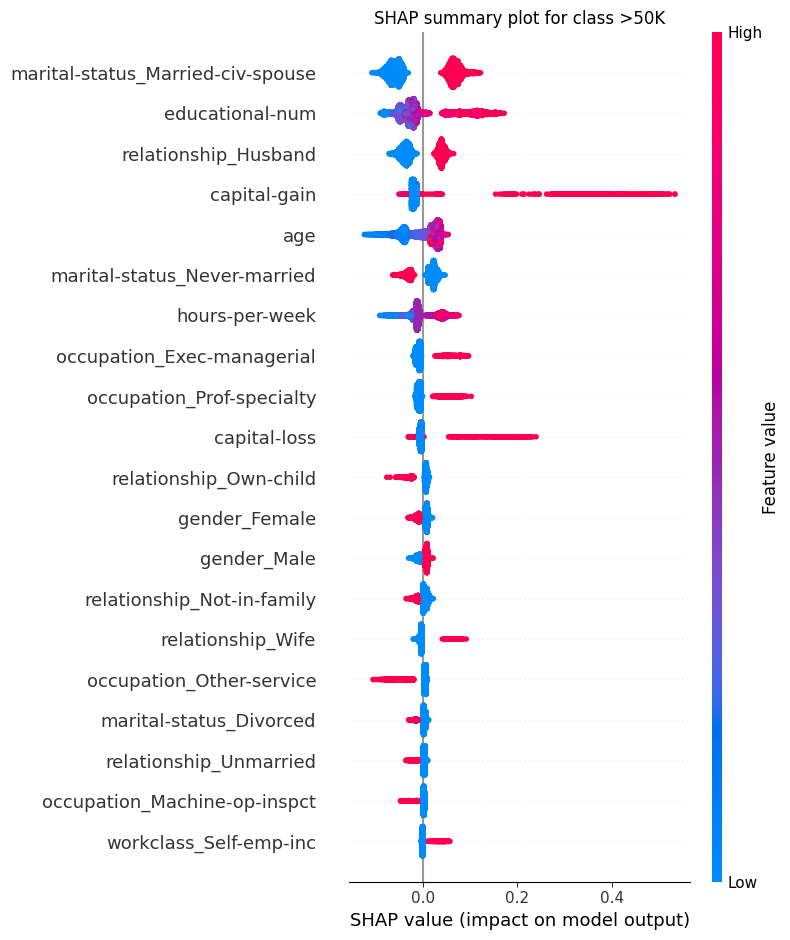

In [146]:
plt.figure()
shap.summary_plot(shap_values_pos, X_test_encoded_df, show=False)
plt.title("SHAP summary plot for class >50K")
plt.tight_layout()
plt.show()

plot shows that the most important features in the model are mostly related to marital status, education, relationship, capital gain, and age.

The strongest positive impact on prediction of class `>50K` can be seen for `marital-status_Married-civ-spouse`, higher `educational-num`, high `capital-gain`, and some occupation categories such as `Exec-managerial` and `Prof-specialty`.

In general, the model predicts higher income mainly for people with higher education, strong capital gains, and more stable family or work-related status. Lower income is more often associated with categories linked to weaker labor market position or less favorable personal status.

From SHAP values we can also calculate global importance numerically. We take mean absolute SHAP value for every feature and sort them descending.

Below we show top 5 most important features globally.

In [148]:
global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_pos.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

top5_features = global_importance.head(5).reset_index(drop=True)
display(top5_features)

,feature,mean_abs_shap
0,marital-status_Married-civ-spouse,0.064265
1,educational-num,0.048749
2,relationship_Husband,0.038769
3,capital-gain,0.035895
4,age,0.030603


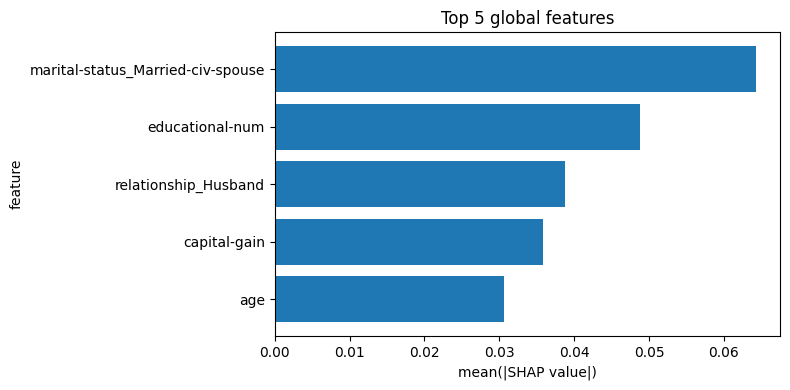

In [149]:
plt.figure(figsize=(8, 4))
plt.barh(top5_features["feature"][::-1], top5_features["mean_abs_shap"][::-1])
plt.xlabel("mean(|SHAP value|)")
plt.ylabel("feature")
plt.title("Top 5 global features")
plt.tight_layout()
plt.show()

To better understand individual features, we draw dependence plots. We use the three strongest features from global ranking.

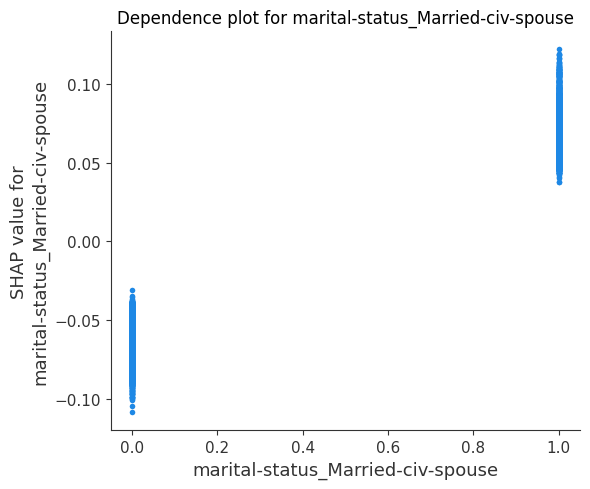

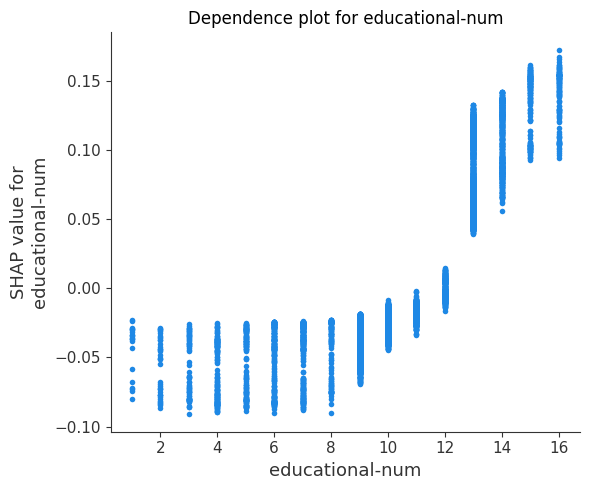

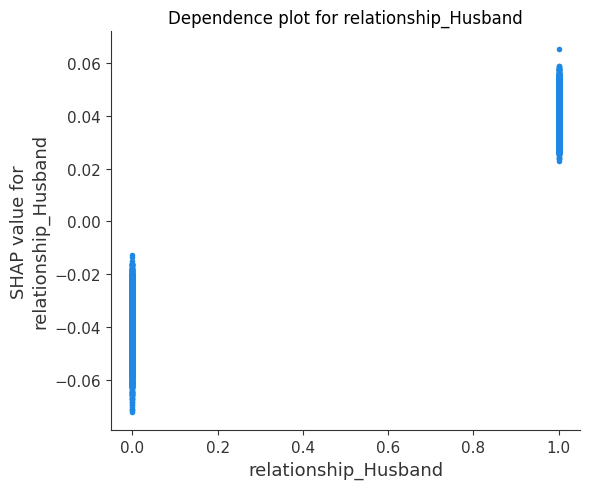

In [150]:
top3_feature_names = top5_features["feature"].head(3).tolist()

for feature in top3_feature_names:
    shap.dependence_plot(
        feature,
        shap_values_pos.values,
        X_test_encoded_df,
        interaction_index=None,
        show=False
    )
    plt.title(f"Dependence plot for {feature}")
    plt.tight_layout()
    plt.show()

The dependence plots show that `marital-status_Married-civ-spouse` and `relationship_Husband` influence the prediction in a very clear way, becouse they are trully one-hot variables. If these variables are equal to 1, they move the prediction toward class `>50K`, and if they are equal to 0, their impact is usually negative.

For `educational-num`, the effect is more continuous, becouse our categorical variable is ordinary. Lower values are connected with negative SHAP values, while higher values increase the chance of predicting income above `$50K$`. This means that higher education level generally supports the positive class in the model.

Now we explain predictions for 2 specific individuals with different outcomes: 1. person correctly predicted as `$<=50K$`, 2. person correctly predicted as `$>50K$`. for each person we show original values, strongest SHAP contributions and force plot.

In [152]:
def explain_one_case(case_name, row_index):
    position = X_test_encoded_df.index.get_loc(row_index)

    sample_original = X_test.loc[row_index]
    sample_encoded = X_test_encoded_df.loc[row_index]
    sample_shap = shap_values_pos[position]

    contributions = pd.DataFrame({
        "feature": feature_names,
        "value": sample_encoded.values,
        "shap_value": sample_shap.values
    })
    contributions["abs_shap"] = contributions["shap_value"].abs()
    contributions = contributions.sort_values("abs_shap", ascending=False)

    print(case_name)
    print("True class:", ">50K" if y_test.loc[row_index] == 1 else "<=50K")
    print("Predicted class:", ">50K" if y_pred[position] == 1 else "<=50K")
    print("Predicted probability of >50K:", round(y_proba[position], 4))
    print()

    print("Original feature values:")
    display(sample_original.to_frame(name="value"))

    print("Top local SHAP contributions:")
    display(contributions.head(10))

    plt.figure(figsize=(15, 3.5))
    shap.force_plot(
        base_value=sample_shap.base_values,
        shap_values=sample_shap.values,
        features=sample_encoded.values,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(case_name)
    plt.tight_layout()
    plt.show()

Person 1: correctly predicted <=50K
True class: <=50K
Predicted class: <=50K
Predicted probability of >50K: 0.3345

Original feature values:


,value
age,31
workclass,Private
fnlwgt,113364
educational-num,12
marital-status,Married-civ-spouse
occupation,Machine-op-inspct
relationship,Husband
race,White
gender,Male
capital-gain,0


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
15,marital-status_Married-civ-spouse,1.0,0.063700,0.063700
5,hours-per-week,55.0,0.041419,0.041419
34,relationship_Husband,1.0,0.037047,0.037047
26,occupation_Machine-op-inspct,1.0,-0.035345,0.035345
0,age,31.0,-0.026042,0.026042
17,marital-status_Never-married,0.0,0.023397,0.023397
3,capital-gain,0.0,-0.022931,0.022931
23,occupation_Exec-managerial,0.0,-0.019656,0.019656
29,occupation_Prof-specialty,0.0,-0.011821,0.011821
35,relationship_Not-in-family,0.0,0.008177,0.008177


<Figure size 1500x350 with 0 Axes>

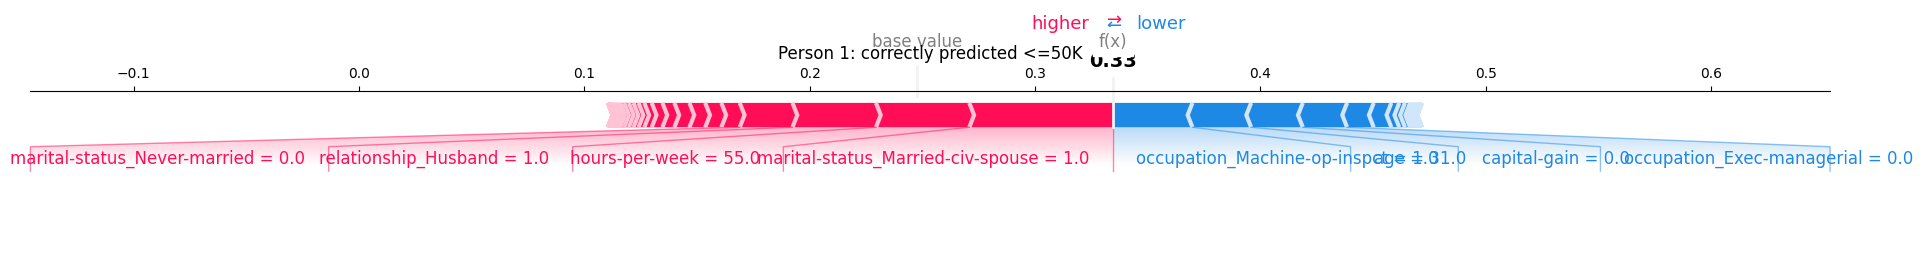

In [158]:
test_results = pd.DataFrame({
    "true_label": y_test.values,
    "pred_label": y_pred,
    "pred_prob_>50K": y_proba
}, index=X_test.index)

correct_low_idx = test_results[
    (test_results["true_label"] == 0) & (test_results["pred_label"] == 0)
].index[0]

explain_one_case("Person 1: correctly predicted <=50K", correct_low_idx)

model correctly predicted class `$<=50K$`, because the final probability of class `$>50K$` was only `0.3345`. Some features increased the prediction, especially `marital-status_Married-civ-spouse`, `relationship_Husband`, and higher `hours-per-week`. At the same time, several important features pushed the prediction down. The strongest negative effects came from `occupation_Machine-op-inspct`, relatively lower `age`, and `capital-gain = 0`.  

This means that even though this person has some characteristics linked with higher income, they were not strong enough to move the prediction above the decision threshold.

Person 2: correctly predicted >50K
True class: >50K
Predicted class: >50K
Predicted probability of >50K: 0.8856

Original feature values:


,value
age,32
workclass,Private
fnlwgt,134737
educational-num,13
marital-status,Married-civ-spouse
occupation,Prof-specialty
relationship,Husband
race,White
gender,Male
capital-gain,99999


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
3,capital-gain,99999.0,0.344209,0.344209
2,educational-num,13.0,0.077254,0.077254
15,marital-status_Married-civ-spouse,1.0,0.052096,0.052096
29,occupation_Prof-specialty,1.0,0.037392,0.037392
34,relationship_Husband,1.0,0.032684,0.032684
5,hours-per-week,50.0,0.030882,0.030882
17,marital-status_Never-married,0.0,0.022798,0.022798
23,occupation_Exec-managerial,0.0,-0.009177,0.009177
37,relationship_Own-child,0.0,0.008723,0.008723
35,relationship_Not-in-family,0.0,0.007397,0.007397


<Figure size 1500x350 with 0 Axes>

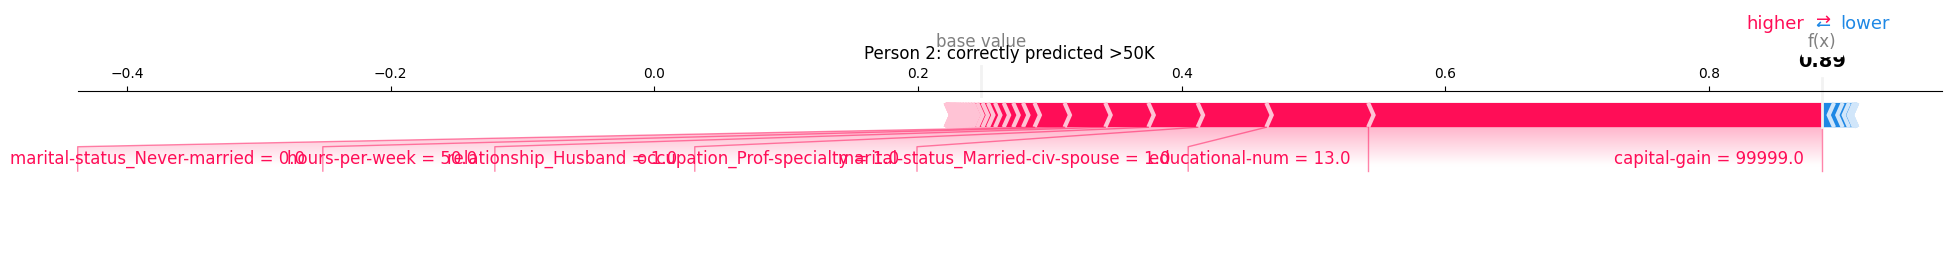

In [156]:
correct_high_idx = test_results[
    (test_results["true_label"] == 1) & (test_results["pred_label"] == 1)
].index[0]
explain_one_case("Person 2: correctly predicted >50K", correct_high_idx)

For Person 2, the model correctly predicted class `>50K`, mainly because of the very strong positive effect of `capital-gain = 99999` (which could be mistake!), supported by higher `educational-num`, `marital-status_Married-civ-spouse`, and `occupation_Prof-specialty`.

These positive contributions clearly pushed the prediction toward high income, giving a final probability of `0.8856`.

Person 3: incorrectly predicted >50K
True class: <=50K
Predicted class: >50K
Predicted probability of >50K: 0.7463

Original feature values:


,value
age,55
workclass,Self-emp-not-inc
fnlwgt,145574
educational-num,9
marital-status,Divorced
occupation,Exec-managerial
relationship,Not-in-family
race,White
gender,Male
capital-gain,34095


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
3,capital-gain,34095.0,0.478929,0.478929
15,marital-status_Married-civ-spouse,0.0,-0.044507,0.044507
5,hours-per-week,60.0,0.042143,0.042143
23,occupation_Exec-managerial,1.0,0.034399,0.034399
34,relationship_Husband,0.0,-0.031554,0.031554
0,age,55.0,0.031302,0.031302
2,educational-num,9.0,-0.029534,0.029534
13,marital-status_Divorced,1.0,-0.012551,0.012551
17,marital-status_Never-married,0.0,0.011777,0.011777
10,workclass_Self-emp-not-inc,1.0,-0.009461,0.009461


<Figure size 1500x350 with 0 Axes>

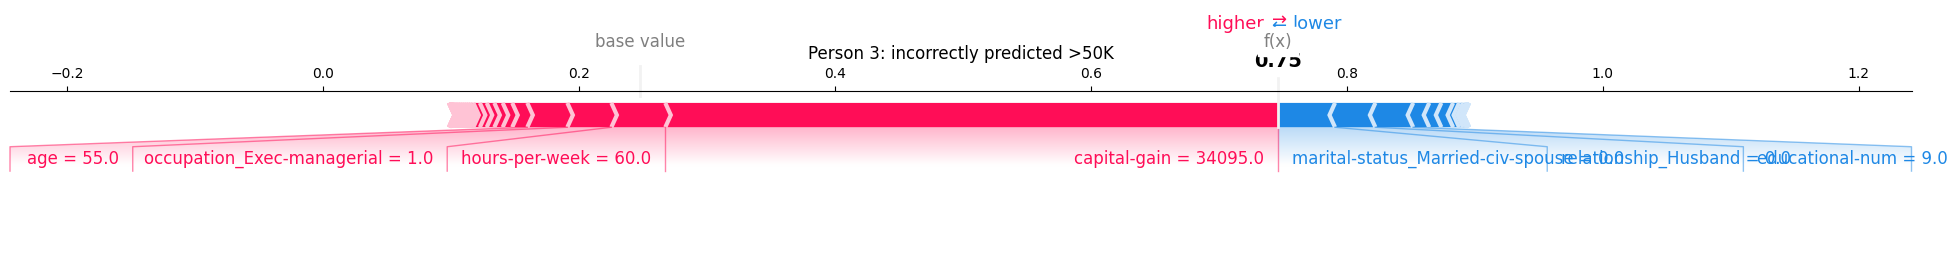

In [159]:
uncorrect_idx = test_results[
    (test_results["true_label"] == 0) & (test_results["pred_label"] == 1)
].index[0]
explain_one_case("Person 3: incorrectly predicted >50K", uncorrect_idx)

here, the model made a wrong prediction and classified this person as `>50K`, mainly because `capital-gain = 34095` had a very strong positive impact on the output. Higher `hours-per-week`, `occupation_Exec-managerial`, and older age also pushed the prediction toward the positive class. At the same time, lower `educational-num`, `marital-status_Divorced`, and the absence of categories such as `Married-civ-spouse` and `Husband` decreased the prediction.

Unfornutatly, these negative effects were weaker than the strong positive contribution of `capital-gain`.